In [26]:
import tensorflow as tf

print("GPU:", tf.config.list_physical_devices('GPU'))

# # Enable mixed precision for faster GPU training
# from tensorflow.keras import mixed_precision
# mixed_precision.set_global_policy('mixed_float16')

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [27]:
import kagglehub
import os

path = kagglehub.dataset_download("adityajn105/flickr8k")

IMAGE_PATH = os.path.join(path, "Images")
CAPTION_PATH = os.path.join(path, "captions.txt")

print("Images:", IMAGE_PATH)
print("Captions:", CAPTION_PATH)

Using Colab cache for faster access to the 'flickr8k' dataset.
Images: /kaggle/input/flickr8k/Images
Captions: /kaggle/input/flickr8k/captions.txt


In [28]:
import pandas as pd
import numpy as np

data = pd.read_csv(CAPTION_PATH)
data.columns = ["image", "caption"]

def clean_caption(text):
    text = text.lower()
    text = ''.join(c for c in text if c.isalpha() or c == ' ')
    text = 'startseq ' + text.strip() + ' endseq'
    return text

data["caption"] = data["caption"].apply(clean_caption)

print(data.head())

                       image  \
0  1000268201_693b08cb0e.jpg   
1  1000268201_693b08cb0e.jpg   
2  1000268201_693b08cb0e.jpg   
3  1000268201_693b08cb0e.jpg   
4  1000268201_693b08cb0e.jpg   

                                             caption  
0  startseq a child in a pink dress is climbing u...  
1  startseq a girl going into a wooden building e...  
2  startseq a little girl climbing into a wooden ...  
3  startseq a little girl climbing the stairs to ...  
4  startseq a little girl in a pink dress going i...  


tokenizer

In [29]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(num_words=5000, oov_token="<unk>")
tokenizer.fit_on_texts(data["caption"])

vocab_size = min(5000, len(tokenizer.word_index)) + 1

lengths = [len(c.split()) for c in data["caption"]]
max_length = int(np.percentile(lengths, 95))

print("Vocab:", vocab_size)
print("Max length:", max_length)

Vocab: 5001
Max length: 20


save tokenizer

In [30]:
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

with open("metadata.pkl", "wb") as f:
    pickle.dump({
        "vocab_size": vocab_size,
        "max_length": max_length
    }, f)

train/validation split

In [31]:
images = data["image"].unique()
split = int(0.8 * len(images))

train_images = images[:split]
val_images = images[split:]

train_data = data[data.image.isin(train_images)]
val_data = data[data.image.isin(val_images)]

efficient tf.data pipeline(gpu optimized)

In [32]:
def create_pairs(df):
    image_paths = []
    captions = []

    for img, cap in zip(df.image, df.caption):
        image_paths.append(os.path.join(IMAGE_PATH, img))
        captions.append(cap)

    return image_paths, captions

train_img_paths, train_caps = create_pairs(train_data)
val_img_paths, val_caps = create_pairs(val_data)

In [33]:
import tensorflow as tf
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.sequence import pad_sequences

def load_and_process(image_path, caption):

    # Load image from disk (lazy)
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (224,224))
    img = preprocess_input(img)

    # Convert caption to sequence
    caption = caption.numpy().decode("utf-8")
    seq = tokenizer.texts_to_sequences([caption])[0]
    seq = pad_sequences([seq], maxlen=max_length)[0]

    return img, seq

In [34]:
def tf_wrapper(image_path, caption):

    img, seq = tf.py_function(
        load_and_process,
        [image_path, caption],
        [tf.float32, tf.int32]
    )

    img.set_shape((224,224,3))
    seq.set_shape((max_length,))

    return img, seq

In [35]:
BATCH_SIZE = 32

train_dataset = tf.data.Dataset.from_tensor_slices(
    (train_img_paths, train_caps)
)

train_dataset = train_dataset.map(
    tf_wrapper,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_dataset = train_dataset.shuffle(1000)\
                             .batch(BATCH_SIZE)\
                             .prefetch(tf.data.AUTOTUNE)


val_dataset = tf.data.Dataset.from_tensor_slices(
    (val_img_paths, val_caps)
)

val_dataset = val_dataset.map(
    tf_wrapper,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_dataset = val_dataset.batch(BATCH_SIZE)\
                         .prefetch(tf.data.AUTOTUNE)

In [36]:
EMBED_DIM = 256
UNITS = 512
EPOCHS = 10

encoder

In [37]:
from tensorflow.keras.applications import ResNet50

class Encoder(tf.keras.Model):
    def __init__(self, embed_dim):
        super().__init__()
        self.cnn = ResNet50(include_top=False, weights="imagenet")
        self.cnn.trainable = False   # freeze initially
        self.fc = tf.keras.layers.Dense(embed_dim)

    def call(self, x):
        x = self.cnn(x)
        x = tf.reshape(x, (x.shape[0], -1, x.shape[3]))  # (batch, 49, 2048)
        x = self.fc(x)
        return tf.nn.relu(x)

bahdanau attention

In [38]:
class BahdanauAttention(tf.keras.layers.Layer):
    def __init__(self, units):
        super().__init__()
        self.W1 = tf.keras.layers.Dense(units)
        self.W2 = tf.keras.layers.Dense(units)
        self.V = tf.keras.layers.Dense(1)

    def call(self, features, hidden):
        hidden = tf.expand_dims(hidden, 1)
        score = tf.nn.tanh(self.W1(features) + self.W2(hidden))
        attention_weights = tf.nn.softmax(self.V(score), axis=1)
        context_vector = attention_weights * features
        context_vector = tf.reduce_sum(context_vector, axis=1)
        return context_vector, attention_weights

decoder



In [39]:
class Decoder(tf.keras.Model):
    def __init__(self, embed_dim, units, vocab_size):
        super().__init__()

        self.units = units
        self.embedding = tf.keras.layers.Embedding(vocab_size, embed_dim)
        self.attention = BahdanauAttention(units)
        self.lstm = tf.keras.layers.LSTM(units, return_sequences=True, return_state=True)
        self.dropout = tf.keras.layers.Dropout(0.5)
        self.fc1 = tf.keras.layers.Dense(units)
        self.fc2 = tf.keras.layers.Dense(vocab_size)

    def call(self, x, features, hidden):

        context_vector, attention_weights = self.attention(features, hidden)

        x = self.embedding(x)
        x = tf.concat([tf.expand_dims(context_vector, 1), x], axis=-1)

        output, state, _ = self.lstm(x)

        x = self.dropout(output)
        x = self.fc1(x)
        x = tf.reshape(x, (-1, x.shape[2]))
        x = self.fc2(x)

        return x, state, attention_weights

loss+optimizer (label smoothing)

In [40]:
optimizer = tf.keras.optimizers.Adam(1e-4)

loss_object = tf.keras.losses.CategoricalCrossentropy(
    from_logits=True,
    reduction="none",
    label_smoothing=0.1
)

def loss_function(real, pred):
    # Convert sparse integer labels to one-hot encoding for CategoricalCrossentropy
    real_one_hot = tf.one_hot(real, depth=vocab_size)

    mask = tf.math.not_equal(real, 0) # Masking still applies to sparse real labels
    loss_ = loss_object(real_one_hot, pred)
    mask = tf.cast(mask, dtype=loss_.dtype)
    loss_ *= mask
    return tf.reduce_mean(loss_)

training step

In [44]:
@tf.function
def train_step(img_tensor, target):

    loss = 0.0
    hidden = tf.zeros((img_tensor.shape[0], UNITS), dtype=tf.float32)

    dec_input = tf.expand_dims(
        [tokenizer.word_index["startseq"]] * img_tensor.shape[0],
        1
    )

    with tf.GradientTape() as tape:

        features = encoder(img_tensor)

        for i in range(1, target.shape[1]):
            predictions, hidden, _ = decoder(dec_input, features, hidden)

            loss += loss_function(target[:, i], predictions)

            dec_input = tf.expand_dims(target[:, i], 1)

    total_loss = loss / tf.cast(target.shape[1], tf.float32)

    variables = encoder.trainable_variables + decoder.trainable_variables
    gradients = tape.gradient(loss, variables)
    optimizer.apply_gradients(zip(gradients, variables))

    return total_loss

instantiate model

In [45]:
encoder = Encoder(EMBED_DIM)
decoder = Decoder(EMBED_DIM, UNITS, vocab_size)

training loop

In [49]:
for epoch in range(EPOCHS):

    total_loss = 0
    step = 0

    for img_batch, cap_batch in train_dataset:

        batch_loss = train_step(img_batch, cap_batch)
        total_loss += batch_loss
        step += 1

        if step % 20 == 0:
            print(f"Epoch {epoch+1} Step {step} Loss {batch_loss:.4f}")

    print(f"\nEpoch {epoch+1} Completed | Avg Loss {total_loss/step:.4f}\n")

    encoder.save_weights("encoder_attention.weights.h5")
    decoder.save_weights("decoder_attention.weights.h5")

Epoch 1 Step 20 Loss 2.7473
Epoch 1 Step 40 Loss 2.9114
Epoch 1 Step 60 Loss 2.8309
Epoch 1 Step 80 Loss 2.5789
Epoch 1 Step 100 Loss 2.5911
Epoch 1 Step 120 Loss 2.6897
Epoch 1 Step 140 Loss 2.5302
Epoch 1 Step 160 Loss 2.3953
Epoch 1 Step 180 Loss 2.9367
Epoch 1 Step 200 Loss 2.4561
Epoch 1 Step 220 Loss 2.6567
Epoch 1 Step 240 Loss 2.6052
Epoch 1 Step 260 Loss 2.6955
Epoch 1 Step 280 Loss 2.9835
Epoch 1 Step 300 Loss 2.6413
Epoch 1 Step 320 Loss 2.6404
Epoch 1 Step 340 Loss 2.7097
Epoch 1 Step 360 Loss 2.6841
Epoch 1 Step 380 Loss 2.4364
Epoch 1 Step 400 Loss 2.7382
Epoch 1 Step 420 Loss 2.6363
Epoch 1 Step 440 Loss 2.8857
Epoch 1 Step 460 Loss 2.5980
Epoch 1 Step 480 Loss 2.5578
Epoch 1 Step 500 Loss 2.3926
Epoch 1 Step 520 Loss 2.5940
Epoch 1 Step 540 Loss 2.5025
Epoch 1 Step 560 Loss 2.6248
Epoch 1 Step 580 Loss 2.5423
Epoch 1 Step 600 Loss 2.5800
Epoch 1 Step 620 Loss 2.5446
Epoch 1 Step 640 Loss 2.3254
Epoch 1 Step 660 Loss 2.5646
Epoch 1 Step 680 Loss 2.6768
Epoch 1 Step 700 L

KeyboardInterrupt: 

Testing the model

In [70]:
def generate_attention_caption_beam(image_path, beam_width=3):

    img = load_img(image_path, target_size=(224,224))
    img = img_to_array(img)
    img = preprocess_input(img)
    img = tf.expand_dims(img, 0)

    features = encoder(img)

    start = tokenizer.word_index["startseq"]
    end = tokenizer.word_index["endseq"]

    sequences = [([start], 0.0, tf.zeros((1, UNITS)))]

    for _ in range(max_length):

        all_candidates = []

        for seq, score, hidden in sequences:

            dec_input = tf.expand_dims([seq[-1]], 0)

            preds, new_hidden, _ = decoder(
                dec_input,
                features,
                hidden
            )

            preds = tf.nn.softmax(preds[0]).numpy()

            top_k = np.argsort(preds)[-beam_width:]

            for word in top_k:

                prob = preds[word]

                candidate = (
                    seq + [word],
                    score - np.log(prob + 1e-9),
                    new_hidden
                )

                all_candidates.append(candidate)

        sequences = sorted(all_candidates, key=lambda x: x[1])[:beam_width]

        # Stop early if all end
        if all(seq[-1] == end for seq, _, _ in sequences):
            break

    final_seq = sequences[0][0]

    caption = [
        tokenizer.index_word.get(i)
        for i in final_seq
        if i not in [start, end]
    ]

    return " ".join(caption)

Image: 514222285_aa0c8d05b7.jpg
Attention Caption: 
------------------------------------------------------------
Image: 847782643_57248bbdab.jpg
Attention Caption: a little boy is sitting in front of a house in front of a house in front of
------------------------------------------------------------
Image: 3678100844_e3a9802471.jpg
Attention Caption: a man in a crowd of a crowd of a crowd of a crowd of a crowd of a
------------------------------------------------------------
Image: 3689727848_b53f931130.jpg
Attention Caption: a swimming pool into a pool into a pool into a pool into a pool
------------------------------------------------------------
Image: 434433505_966e50e17d.jpg
Attention Caption: a blue shirt is rock
------------------------------------------------------------


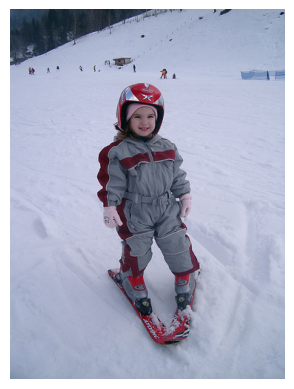

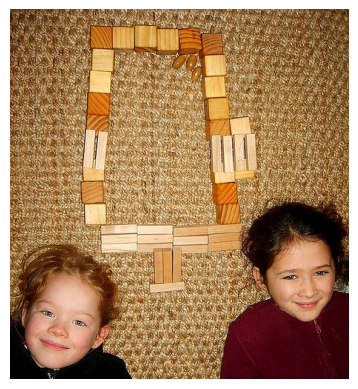

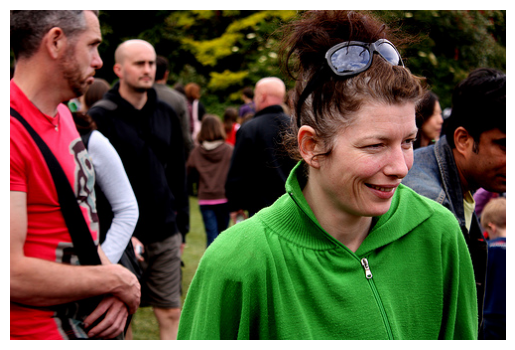

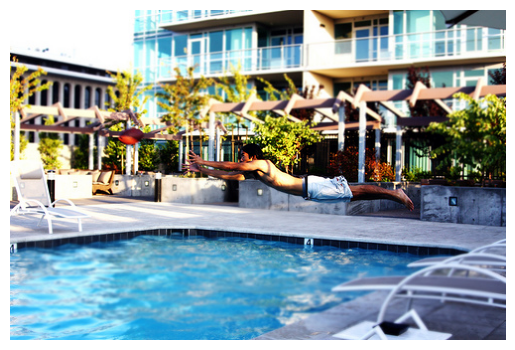

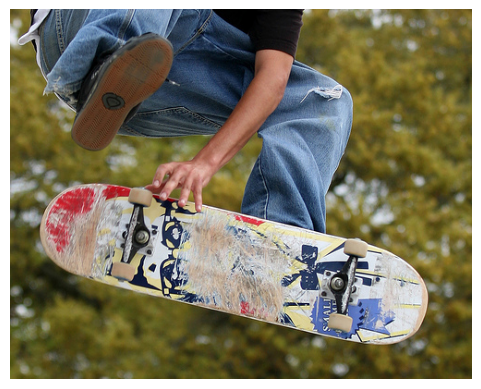

In [71]:
import random
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img

# Pick 5 random validation images
sample_images = random.sample(
    list(val_data.image.unique()), 5
)

for img_name in sample_images:

    img_path = os.path.join(IMAGE_PATH, img_name)

    # Generate caption
    caption = generate_attention_caption_beam(img_path)

    # Display image
    img = load_img(img_path)
    plt.figure()
    plt.imshow(img)
    plt.axis("off")

    print("Image:", img_name)
    print("Attention Caption:", caption)
    print("-" * 60)